# Training Comparison: From Scratch vs ImageNet Pretrained

Detailed side-by-side comparison of two YOLOv5n training approaches:
- **From Scratch** (exp7): Training with random initialization
- **ImageNet Pretrained** (exp6): Fine-tuning from ImageNet weights

Both models trained on Pascal VOC dataset for object detection.

In [6]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import torch

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (18, 10)

print("✅ Environment configured")

✅ Environment configured


## 1. Load Training Results from Both Experiments

In [7]:
# Define both experiments
experiments = {
    'From Scratch': Path('../runs/train/exp7'),
    'ImageNet Pretrained': Path('../runs/train/exp10')
}

# Load results
results = {}
for name, exp_path in experiments.items():
    results_path = exp_path / 'results.csv'
    if results_path.exists():
        df = pd.read_csv(results_path)
        df.columns = df.columns.str.strip()
        results[name] = {
            'df': df,
            'path': exp_path
        }
        print(f"✅ {name:25s}: {len(df)} epochs")
    else:
        print(f"⚠️  {name}: results.csv not found")

print(f"\nLoaded {len(results)} experiments for comparison")

✅ From Scratch             : 100 epochs
✅ ImageNet Pretrained      : 100 epochs

Loaded 2 experiments for comparison


## 2. Summary Statistics Comparison

In [8]:
print("="*80)
print("TRAINING SUMMARY COMPARISON")
print("="*80)

summary_data = []

for name, data in results.items():
    df = data['df']
    
    # Find best epoch
    best_idx = df['metrics/mAP_0.5:0.95'].idxmax()
    best_epoch = df.loc[best_idx]
    final_epoch = df.iloc[-1]
    
    print(f"\n{name.upper()}:")
    print(f"{"-"*80}")
    print(f"Total Epochs:        {len(df)}")
    print(f"Best Epoch:          {int(best_epoch['epoch'])}")
    print(f"\nBest Performance:")
    print(f"  mAP@0.5:0.95:      {best_epoch['metrics/mAP_0.5:0.95']:.4f}")
    print(f"  mAP@0.5:           {best_epoch['metrics/mAP_0.5']:.4f}")
    print(f"  Precision:         {best_epoch['metrics/precision']:.4f}")
    print(f"  Recall:            {best_epoch['metrics/recall']:.4f}")
    print(f"\nFinal Performance (Epoch {int(final_epoch['epoch'])}):")
    print(f"  mAP@0.5:0.95:      {final_epoch['metrics/mAP_0.5:0.95']:.4f}")
    print(f"  mAP@0.5:           {final_epoch['metrics/mAP_0.5']:.4f}")
    print(f"  Precision:         {final_epoch['metrics/precision']:.4f}")
    print(f"  Recall:            {final_epoch['metrics/recall']:.4f}")
    
    # Convergence analysis
    target_map = best_epoch['metrics/mAP_0.5:0.95'] * 0.9
    conv_epochs = df[df['metrics/mAP_0.5:0.95'] >= target_map]
    epochs_to_90 = int(conv_epochs.iloc[0]['epoch']) if len(conv_epochs) > 0 else len(df)
    print(f"\nConvergence:")
    print(f"  Epochs to 90% best: {epochs_to_90}")
    
    summary_data.append({
        'Model': name,
        'Best Epoch': int(best_epoch['epoch']),
        'Best mAP': best_epoch['metrics/mAP_0.5:0.95'],
        'Final mAP': final_epoch['metrics/mAP_0.5:0.95'],
        'Best Precision': best_epoch['metrics/precision'],
        'Best Recall': best_epoch['metrics/recall'],
        'Epochs to 90%': epochs_to_90
    })

print("\n" + "="*80)

# Create summary table
summary_df = pd.DataFrame(summary_data)
print("\nCOMPARISON TABLE:")
print(summary_df.to_string(index=False))

TRAINING SUMMARY COMPARISON

FROM SCRATCH:
--------------------------------------------------------------------------------
Total Epochs:        100
Best Epoch:          94

Best Performance:
  mAP@0.5:0.95:      0.3850
  mAP@0.5:           0.6572
  Precision:         0.6769
  Recall:            0.6169

Final Performance (Epoch 99):
  mAP@0.5:0.95:      0.3847
  mAP@0.5:           0.6565
  Precision:         0.6813
  Recall:            0.6124

Convergence:
  Epochs to 90% best: 60

IMAGENET PRETRAINED:
--------------------------------------------------------------------------------
Total Epochs:        100
Best Epoch:          97

Best Performance:
  mAP@0.5:0.95:      0.5046
  mAP@0.5:           0.7667
  Precision:         0.7574
  Recall:            0.7111

Final Performance (Epoch 99):
  mAP@0.5:0.95:      0.5042
  mAP@0.5:           0.7665
  Precision:         0.7551
  Recall:            0.7158

Convergence:
  Epochs to 90% best: 50


COMPARISON TABLE:
              Model  Best Epo

## 3. Detailed Training Metrics Comparison


✅ Saved detailed comparison to: detailed_training_comparison.png


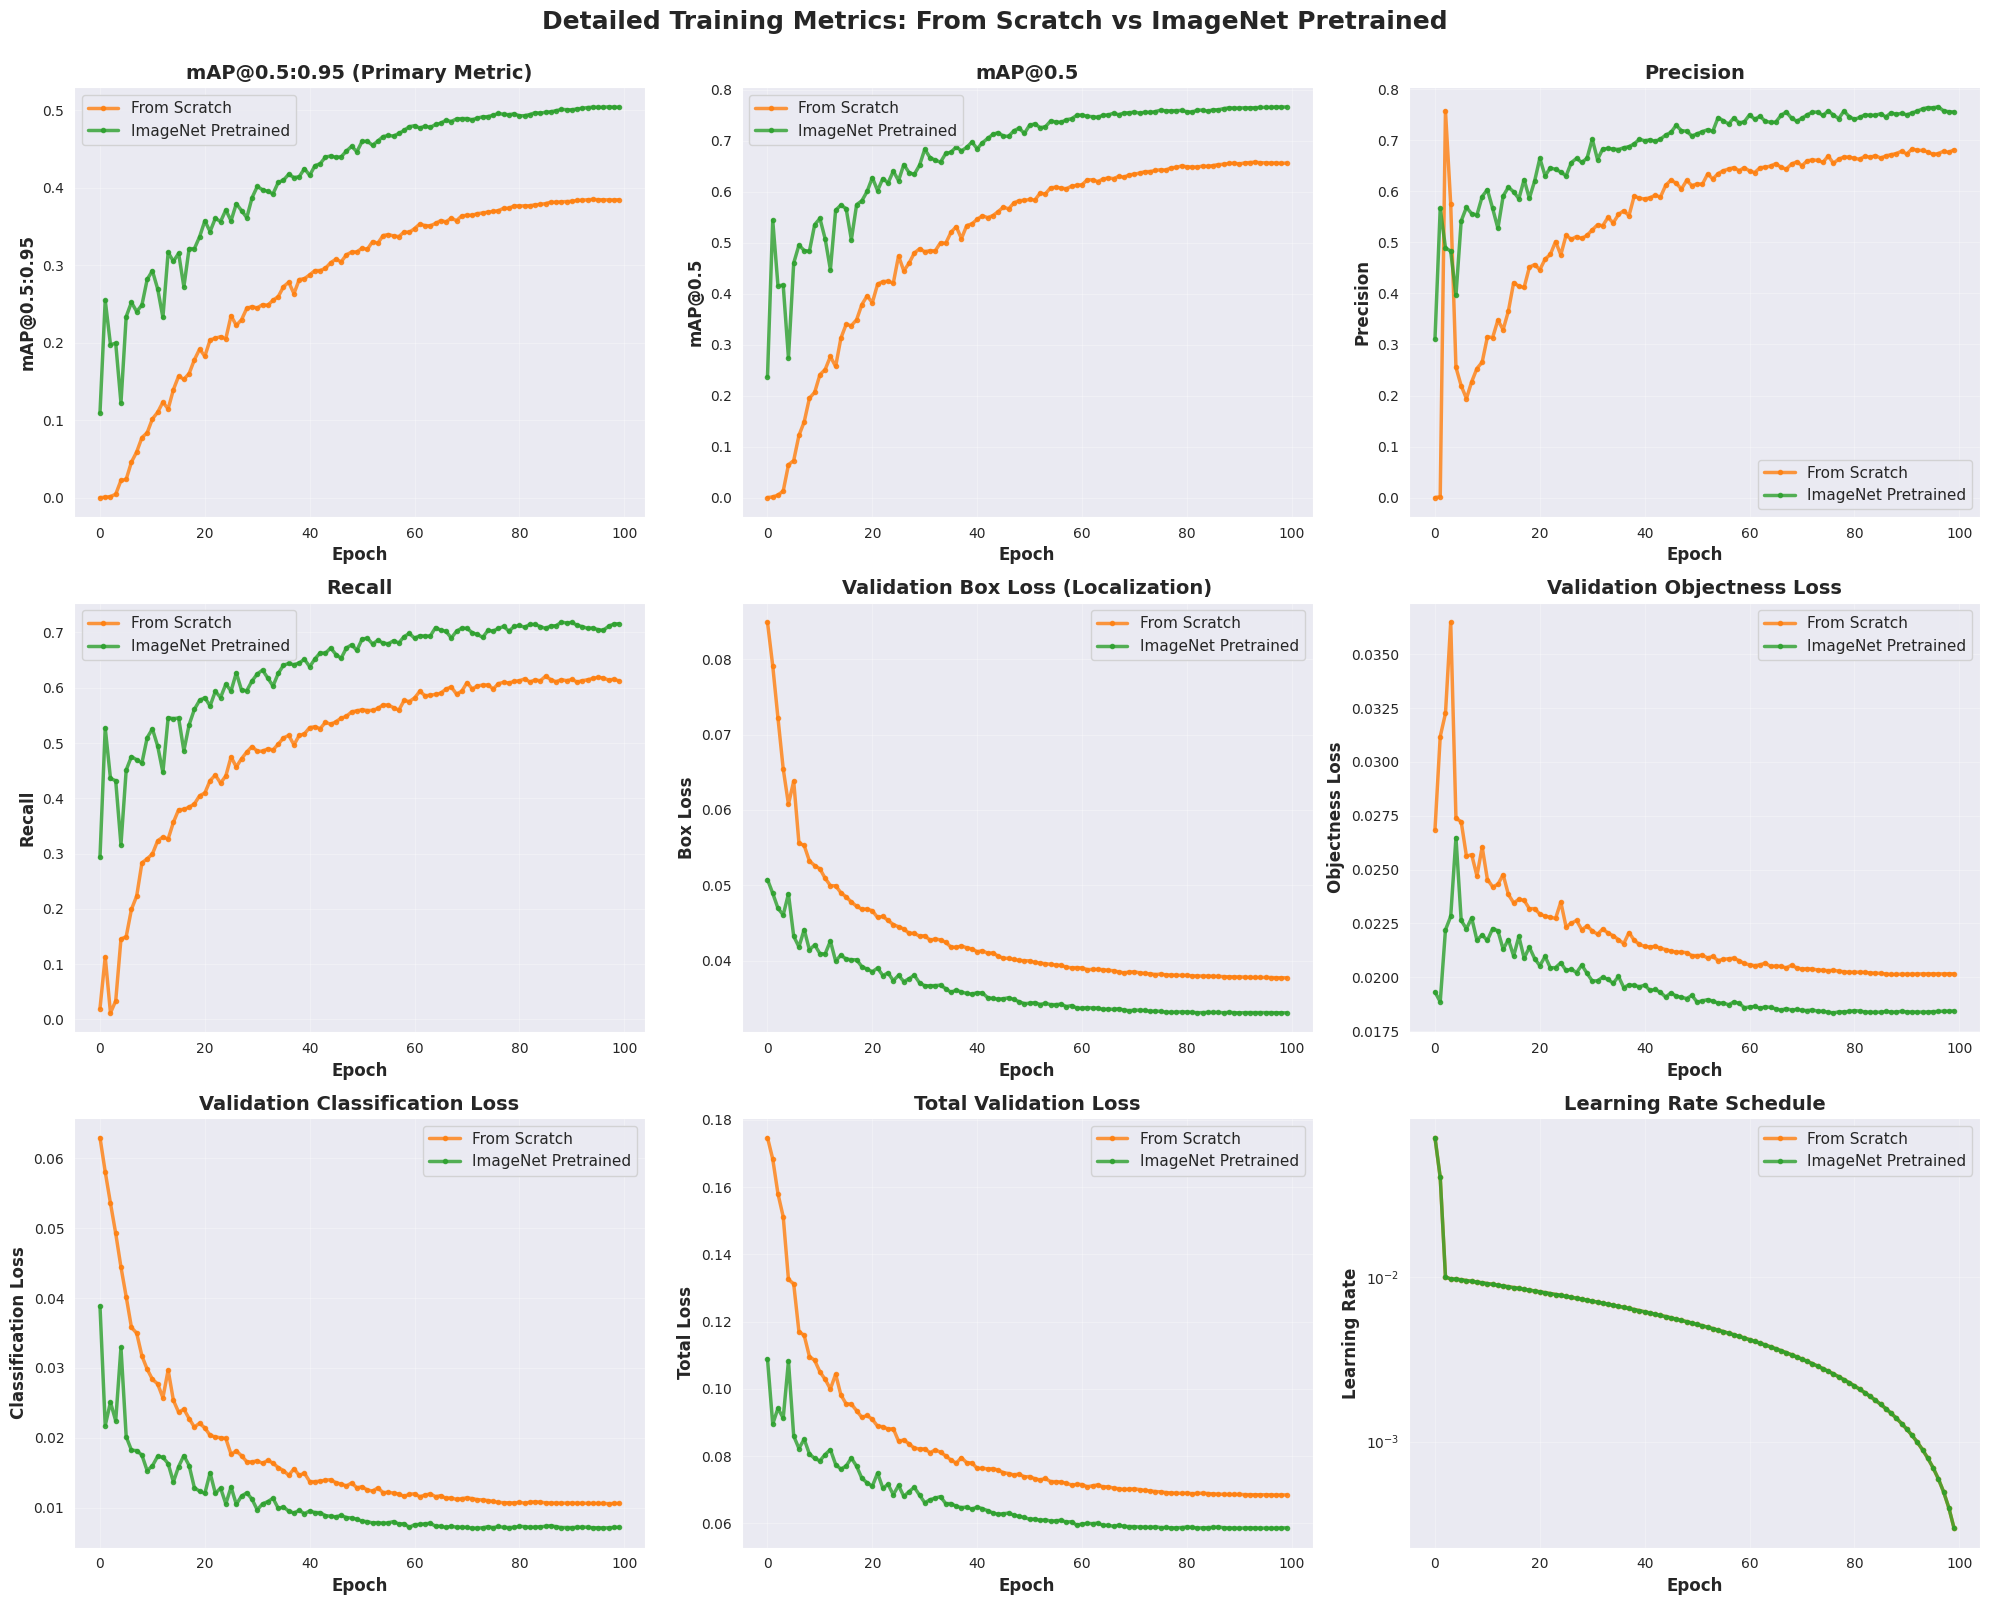

In [9]:
# Create comprehensive comparison plots
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
colors = {'From Scratch': '#ff7f0e', 'ImageNet Pretrained': '#2ca02c'}

# 1. mAP@0.5:0.95 (COCO metric)
for name, data in results.items():
    df = data['df']
    axes[0, 0].plot(df['epoch'], df['metrics/mAP_0.5:0.95'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('mAP@0.5:0.95', fontsize=12, weight='bold')
axes[0, 0].set_title('mAP@0.5:0.95 (Primary Metric)', fontsize=14, weight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. mAP@0.5
for name, data in results.items():
    df = data['df']
    axes[0, 1].plot(df['epoch'], df['metrics/mAP_0.5'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[0, 1].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('mAP@0.5', fontsize=12, weight='bold')
axes[0, 1].set_title('mAP@0.5', fontsize=14, weight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision
for name, data in results.items():
    df = data['df']
    axes[0, 2].plot(df['epoch'], df['metrics/precision'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[0, 2].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0, 2].set_ylabel('Precision', fontsize=12, weight='bold')
axes[0, 2].set_title('Precision', fontsize=14, weight='bold')
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(True, alpha=0.3)

# 4. Recall
for name, data in results.items():
    df = data['df']
    axes[1, 0].plot(df['epoch'], df['metrics/recall'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[1, 0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('Recall', fontsize=12, weight='bold')
axes[1, 0].set_title('Recall', fontsize=14, weight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 5. Box Loss
for name, data in results.items():
    df = data['df']
    axes[1, 1].plot(df['epoch'], df['val/box_loss'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[1, 1].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[1, 1].set_ylabel('Box Loss', fontsize=12, weight='bold')
axes[1, 1].set_title('Validation Box Loss (Localization)', fontsize=14, weight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# 6. Objectness Loss
for name, data in results.items():
    df = data['df']
    axes[1, 2].plot(df['epoch'], df['val/obj_loss'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[1, 2].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[1, 2].set_ylabel('Objectness Loss', fontsize=12, weight='bold')
axes[1, 2].set_title('Validation Objectness Loss', fontsize=14, weight='bold')
axes[1, 2].legend(fontsize=11)
axes[1, 2].grid(True, alpha=0.3)

# 7. Classification Loss
for name, data in results.items():
    df = data['df']
    axes[2, 0].plot(df['epoch'], df['val/cls_loss'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[2, 0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[2, 0].set_ylabel('Classification Loss', fontsize=12, weight='bold')
axes[2, 0].set_title('Validation Classification Loss', fontsize=14, weight='bold')
axes[2, 0].legend(fontsize=11)
axes[2, 0].grid(True, alpha=0.3)

# 8. Total Loss (combined)
for name, data in results.items():
    df = data['df']
    total_loss = df['val/box_loss'] + df['val/obj_loss'] + df['val/cls_loss']
    axes[2, 1].plot(df['epoch'], total_loss, 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[2, 1].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[2, 1].set_ylabel('Total Loss', fontsize=12, weight='bold')
axes[2, 1].set_title('Total Validation Loss', fontsize=14, weight='bold')
axes[2, 1].legend(fontsize=11)
axes[2, 1].grid(True, alpha=0.3)

# 9. Learning Rate
for name, data in results.items():
    df = data['df']
    axes[2, 2].plot(df['epoch'], df['x/lr0'], 
                   label=name, linewidth=2.5, color=colors[name], marker='o', markersize=3, alpha=0.8)
axes[2, 2].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[2, 2].set_ylabel('Learning Rate', fontsize=12, weight='bold')
axes[2, 2].set_title('Learning Rate Schedule', fontsize=14, weight='bold')
axes[2, 2].legend(fontsize=11)
axes[2, 2].grid(True, alpha=0.3)
axes[2, 2].set_yscale('log')

plt.suptitle('Detailed Training Metrics: From Scratch vs ImageNet Pretrained', 
            fontsize=18, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig('detailed_training_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved detailed comparison to: detailed_training_comparison.png")
plt.show()

## 4. Convergence Speed Analysis


✅ Saved convergence analysis to: convergence_comparison.png


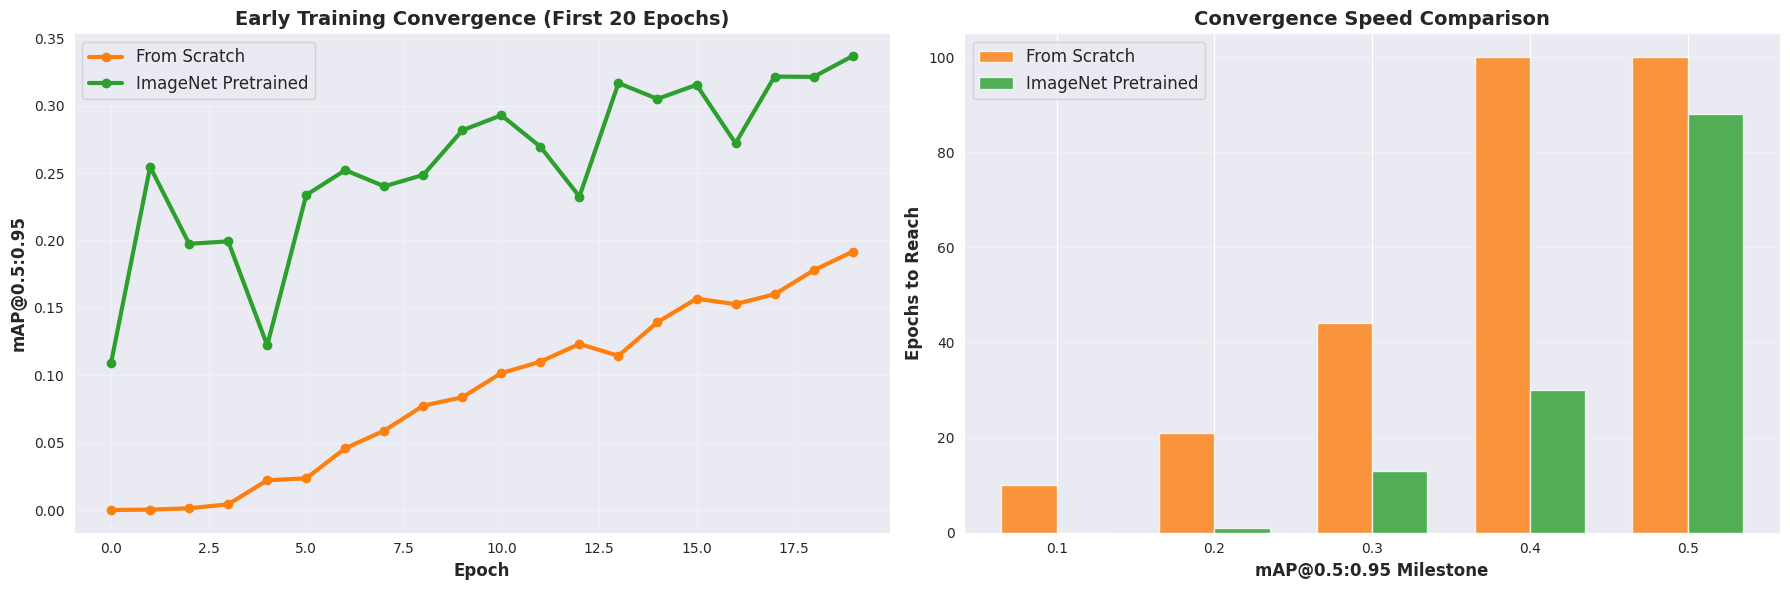

In [10]:
# Analyze how quickly each model converges
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Early training (first 20 epochs)
for name, data in results.items():
    df = data['df'].head(20)
    axes[0].plot(df['epoch'], df['metrics/mAP_0.5:0.95'], 
                label=name, linewidth=3, color=colors[name], marker='o', markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0].set_ylabel('mAP@0.5:0.95', fontsize=12, weight='bold')
axes[0].set_title('Early Training Convergence (First 20 Epochs)', fontsize=14, weight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: Time to reach milestones
milestones = [0.1, 0.2, 0.3, 0.4, 0.5]
milestone_epochs = {name: [] for name in results.keys()}

for name, data in results.items():
    df = data['df']
    for milestone in milestones:
        matching = df[df['metrics/mAP_0.5:0.95'] >= milestone]
        epoch = int(matching.iloc[0]['epoch']) if len(matching) > 0 else len(df)
        milestone_epochs[name].append(epoch)

x = np.arange(len(milestones))
width = 0.35
names = list(results.keys())

axes[1].bar(x - width/2, milestone_epochs[names[0]], width, 
           label=names[0], color=colors[names[0]], alpha=0.8)
axes[1].bar(x + width/2, milestone_epochs[names[1]], width, 
           label=names[1], color=colors[names[1]], alpha=0.8)

axes[1].set_xlabel('mAP@0.5:0.95 Milestone', fontsize=12, weight='bold')
axes[1].set_ylabel('Epochs to Reach', fontsize=12, weight='bold')
axes[1].set_title('Convergence Speed Comparison', fontsize=14, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{m:.1f}' for m in milestones])
axes[1].legend(fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved convergence analysis to: convergence_comparison.png")
plt.show()